# Notebook 09 - Uncertainty Quantification (Second version)

City-agnostic improved workflow for **Copenhagen**. This version keeps the original March 2026 `NB09` untouched and adds three targeted improvements:
- spatially explicit daily raster modifiers for trees and waste heat
- event-level warning-day logic for EWS
- EWS CBA uncertainty outputs alongside the impact uncertainty outputs

All new outputs are written to `outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/` so the original `NB09` outputs remain unchanged.


In [1]:
import os
os.environ["URBAN_HEAT_OUTPUT_VARIANT"] = "masselot_main"
os.environ["IF_MAIN_FAMILY"] = "masselot_tail"


In [2]:
import os
import sys
from pathlib import Path

os.environ.setdefault('CITY', 'copenhagen')
os.environ.setdefault('NB09_N', '512')
os.environ.setdefault('NB09_SEED', '42')
os.environ.setdefault('NB09_MAKE_FIGURES', '0')
os.environ.setdefault('HAZARD_TRACK', 'standard')  # Masselot main: city-specific MMT makes Track-B unnecessary for Copenhagen

def _find_repo_root():
    env = os.environ.get("URBAN_HEAT_ROOT")
    if env:
        root = Path(env).expanduser().resolve()
        if (root / "cityheat").is_dir() and (root / "configs").is_dir():
            return root
    start = Path.cwd().resolve()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError(
        "Could not locate repo root. Run the notebook from inside the repo "
        "or set URBAN_HEAT_ROOT."
    )

ROOT = _find_repo_root()
output_variant = os.environ.get('URBAN_HEAT_OUTPUT_VARIANT', '').strip()
if not output_variant:
    raise RuntimeError('Masselot-main NB09 requires URBAN_HEAT_OUTPUT_VARIANT.')
OUTPUT_ROOT = ROOT / 'outputs_variants' / output_variant
os.environ.setdefault('MPLCONFIGDIR', str(OUTPUT_ROOT / '.mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(OUTPUT_ROOT / '.cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)
print('CITY:', os.environ['CITY'])
print('NB09_N:', os.environ['NB09_N'])
print('NB09_SEED:', os.environ['NB09_SEED'])


ROOT: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat
CITY: copenhagen
NB09_N: 512
NB09_SEED: 42


In [3]:
import logging, warnings, os
warnings.filterwarnings('ignore', category=FutureWarning)
for _name in ['climada', 'climada.hazard', 'climada.hazard.base', 'SALib']:
    logging.getLogger(_name).setLevel(logging.ERROR)
print('NB09 Masselot-main full run: city=copenhagen, N=512, seed=42, figures enabled')
print('URBAN_HEAT_OUTPUT_VARIANT=', os.environ.get('URBAN_HEAT_OUTPUT_VARIANT'))
print('IF_MAIN_FAMILY=', os.environ.get('IF_MAIN_FAMILY'))

NB09 Masselot-main full run: city=copenhagen, N=512, seed=42, figures enabled
URBAN_HEAT_OUTPUT_VARIANT= masselot_main
IF_MAIN_FAMILY= masselot_tail


In [4]:
from cityheat.nb09_improved_fast_masselot_main import run_nb09_improved_fast

paths = run_nb09_improved_fast()
paths


[NB09 masselot-main] Run type: masselot_headline_lhs_band — Masselot extrapolation-bracketed LHS over ['masselot_tail', 'masselot']; output dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast


[copenhagen] sample 1/512: year=2050 aai=0.021


[copenhagen] sample 2/512: year=2040 aai=0.018


[copenhagen] sample 3/512: year=2040 aai=0.006


[copenhagen] sample 4/512: year=2020 aai=0.004


...

[copenhagen] sample 512/512: year=2020 aai=0.000


/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:142: RuntimeWarning: invalid value encountered in scalar divide
  cv = np.nanstd(p_ind) / mean
/opt/an

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

{'headline_unc_dir': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast'),
 'headline__samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/unc_samples_copenhagen_improved_fast.csv'),
 'samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/unc_samples_copenhagen_improved_fast.csv'),
 'headline__impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/unc_impact_summary_copenhagen_improved_fast.csv'),
 'impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/unc_impact_

In [5]:
import pandas as pd

samples = pd.read_csv(paths['samples'])
samples[[
    'year', 'aai_agg', 'annual_deaths', 'sample_warning_days',
    'sample_threshold_deaths_per_day', 'ews_pv_cost_25y',
    'ews_net_avoided_deaths_25y_cum', 'ews_cost_per_net_death_25y_cum'
]].head(10)

,year,aai_agg,annual_deaths,sample_warning_days,sample_threshold_deaths_per_day,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_cost_per_net_death_25y_cum
0,2050,0.020783,7.585728,47.0,0.031846,5.594536e+06,5.191619,1.077609e+06
1,2040,0.018136,6.637868,41.0,0.036255,3.655772e+06,12.229602,2.989282e+05
2,2040,0.005802,2.123650,31.0,0.009052,4.943261e+06,3.056575,1.617255e+06
3,2020,0.004275,1.564615,10.0,0.060941,1.900730e+06,20.233680,9.393892e+04
4,2050,0.006764,2.468911,36.0,0.008837,7.899767e+06,2.683210,2.944147e+06
5,2040,0.004630,1.694556,15.0,0.051740,1.101129e+06,6.850223,1.607435e+05
6,2050,0.014346,5.236413,60.0,0.006481,3.902521e+06,5.294267,7.371221e+05
7,2040,0.013062,4.780718,39.0,0.034303,3.382845e+06,17.978578,1.881597e+05
8,2050,0.032537,11.876045,53.0,0.049080,2.639671e+06,7.942090,3.323648e+05
9,2020,0.003516,1.286718,23.0,0.008420,3.519390e+06,3.130120,1.124363e+06


In [6]:
impact_summary = pd.read_csv(paths['impact'])
cba_summary = pd.read_csv(paths['cba'])

display(impact_summary.describe())
display(cba_summary.describe())

,aai_agg,annual_deaths,rp2,rp5,rp10,rp20
count,512.000000,512.000000,512.0,5.120000e+02,512.000000,512.000000
mean,0.010803,3.947595,0.0,3.915880e-05,0.021801,0.076317
std,0.007493,2.736975,0.0,3.262239e-04,0.025243,0.057392
min,0.002010,0.733618,0.0,0.000000e+00,0.000069,0.007140
25%,0.004300,1.573654,0.0,0.000000e+00,0.000973,0.025489
50%,0.009263,3.380894,0.0,0.000000e+00,0.013934,0.067142
75%,0.015174,5.543948,0.0,4.582366e-07,0.036957,0.111045
max,0.039518,14.463660,0.0,7.071258e-03,0.130241,0.291797


,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_net_avoided_deaths_25y_pv,ews_cost_per_net_death_25y_cum,ews_cost_per_net_death_25y_pv,ews_life_years_saved_25y_cum
count,5.120000e+02,512.000000,512.000000,5.120000e+02,5.120000e+02,512.000000
mean,4.658623e+06,7.913077,4.880826,1.001057e+06,1.596326e+06,102.219699
std,2.686025e+06,6.653022,4.221074,1.028487e+06,1.534074e+06,86.055530
min,9.238794e+05,0.555808,0.289870,9.393892e+04,1.389800e+05,6.963660
25%,2.646540e+06,3.141604,1.909776,3.842573e+05,6.375777e+05,41.372016
50%,3.928399e+06,5.775702,3.614944,6.786375e+05,1.139231e+06,75.332396
75%,6.243211e+06,10.542700,6.241582,1.199428e+06,1.912612e+06,137.980097
max,1.558377e+07,41.004741,28.193584,1.055066e+07,1.439635e+07,526.678584


## Masselot-main NB09 output paths

- bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/unc_impact_copenhagen_march2026_improved_fast.h5

- bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/unc_impact_copenhagen_march2026_improved_fast_with_sensitivity.h5

- burke_sensitivity_burke_polynomial__bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_copenhagen_march2026_improved_fast.h5

- burke_sensitivity_burke_polynomial__bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_copenhagen_march2026_improved_fast_with_sensitivity.h5

...

- vuln: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/copenhagen/tables/uncertainty_improved_fast/unc_vulnerability_copenhagen_improved_fast.csv

## Headline sample IF-family counts

,n
if_family,
masselot,256
masselot_tail,256


## Generated headline NB09 figures

### unc_distribution_aai_agg_copenhagen_improved_fast.png

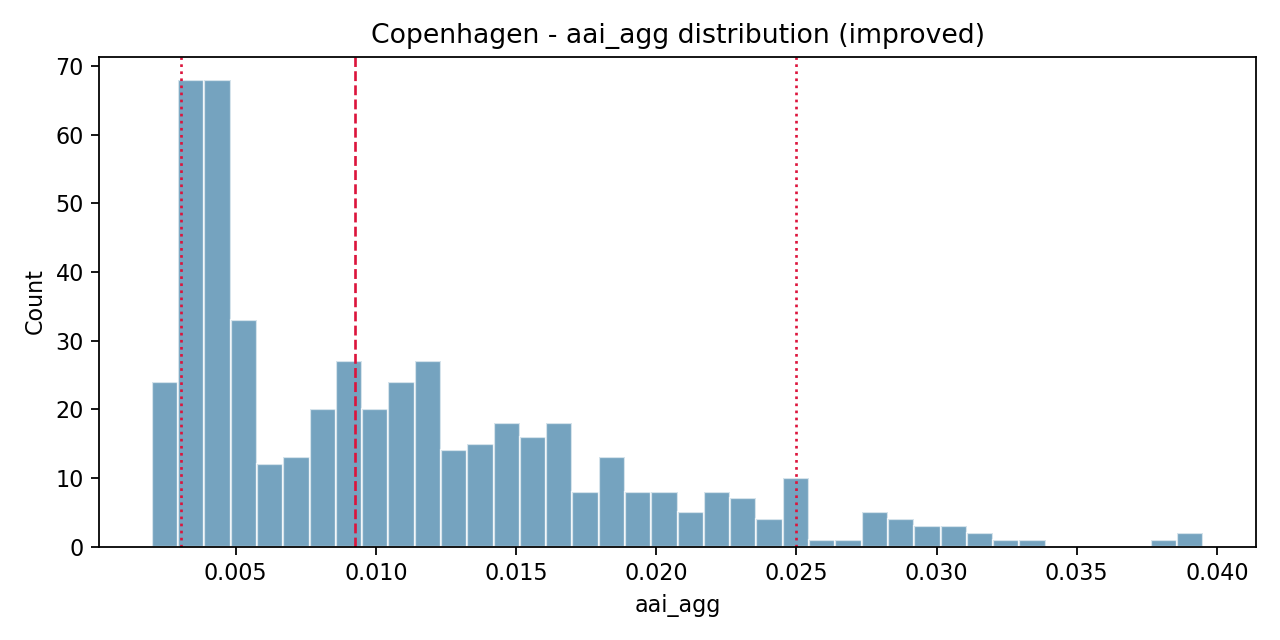

### unc_cdf_aai_agg_copenhagen_improved_fast.png

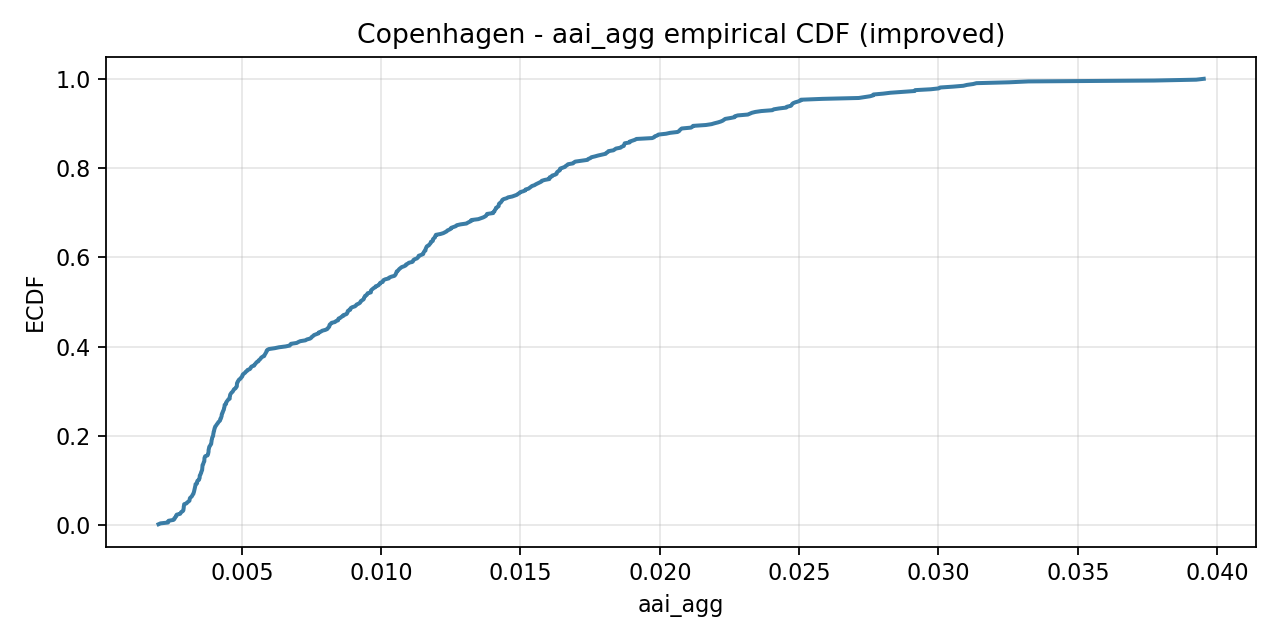

### sens_tornado_aai_agg_copenhagen_improved_fast.png

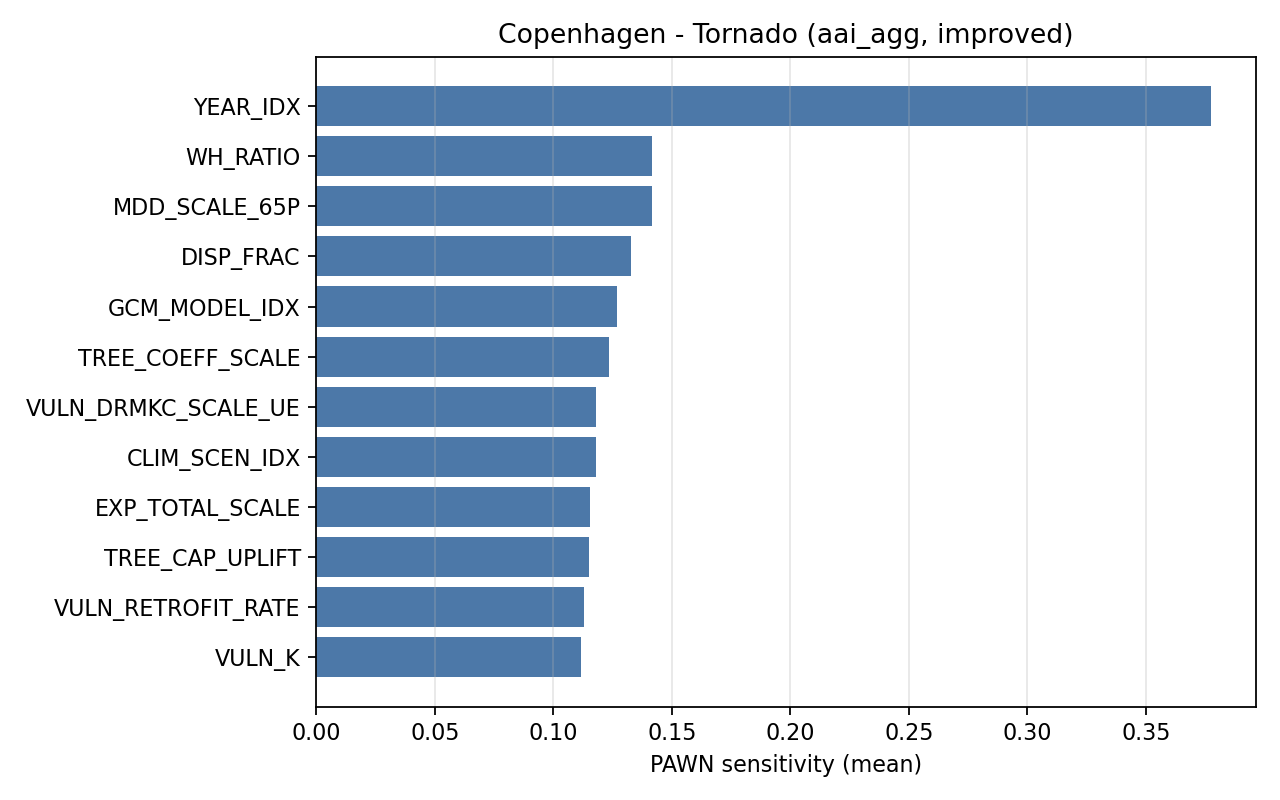

### unc_distribution_cba_ews_copenhagen_improved_fast.png

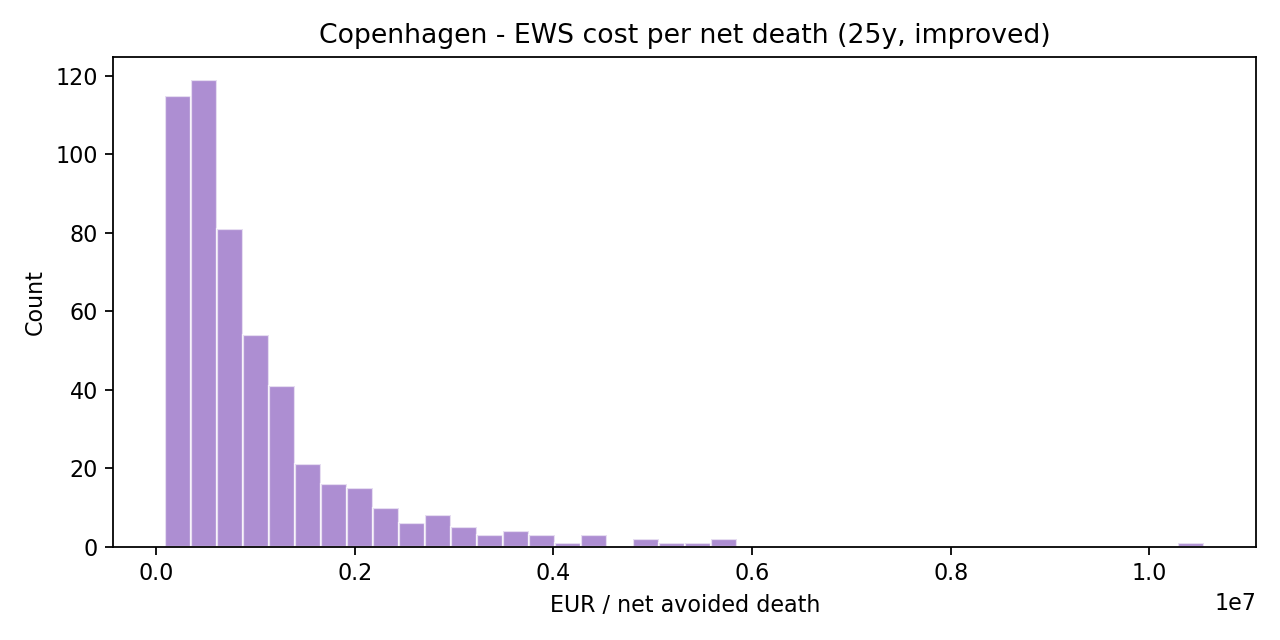

### unc_cdf_cba_ews_copenhagen_improved_fast.png

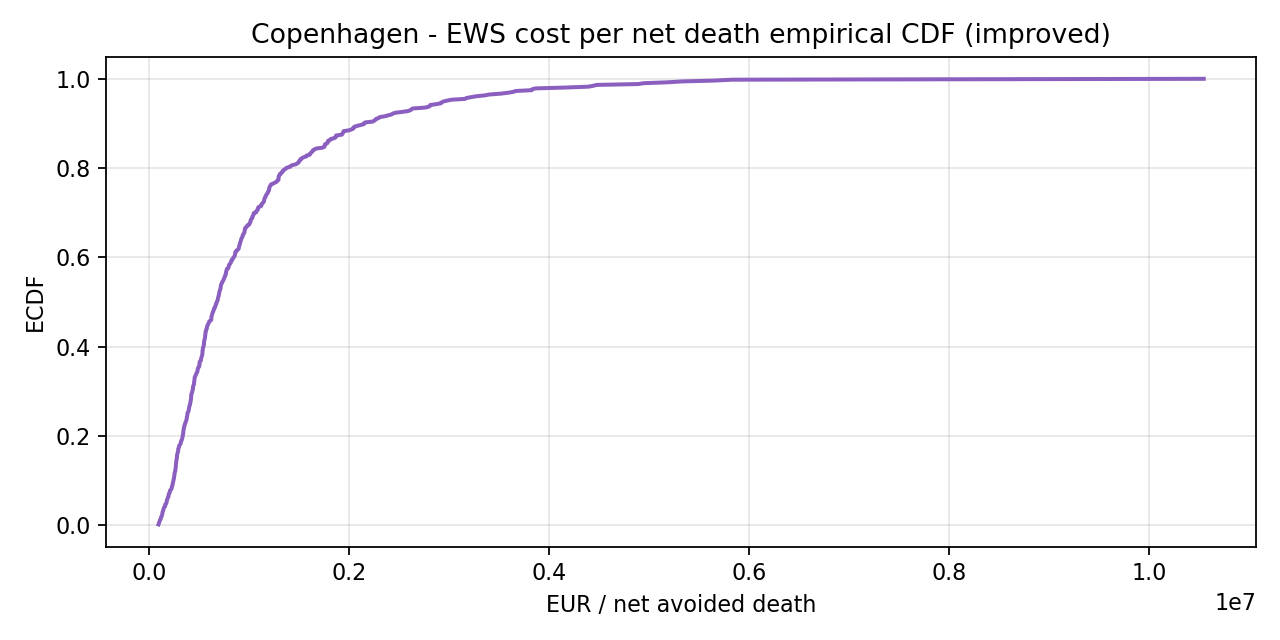

### sens_tornado_cba_ews_copenhagen_improved_fast.png

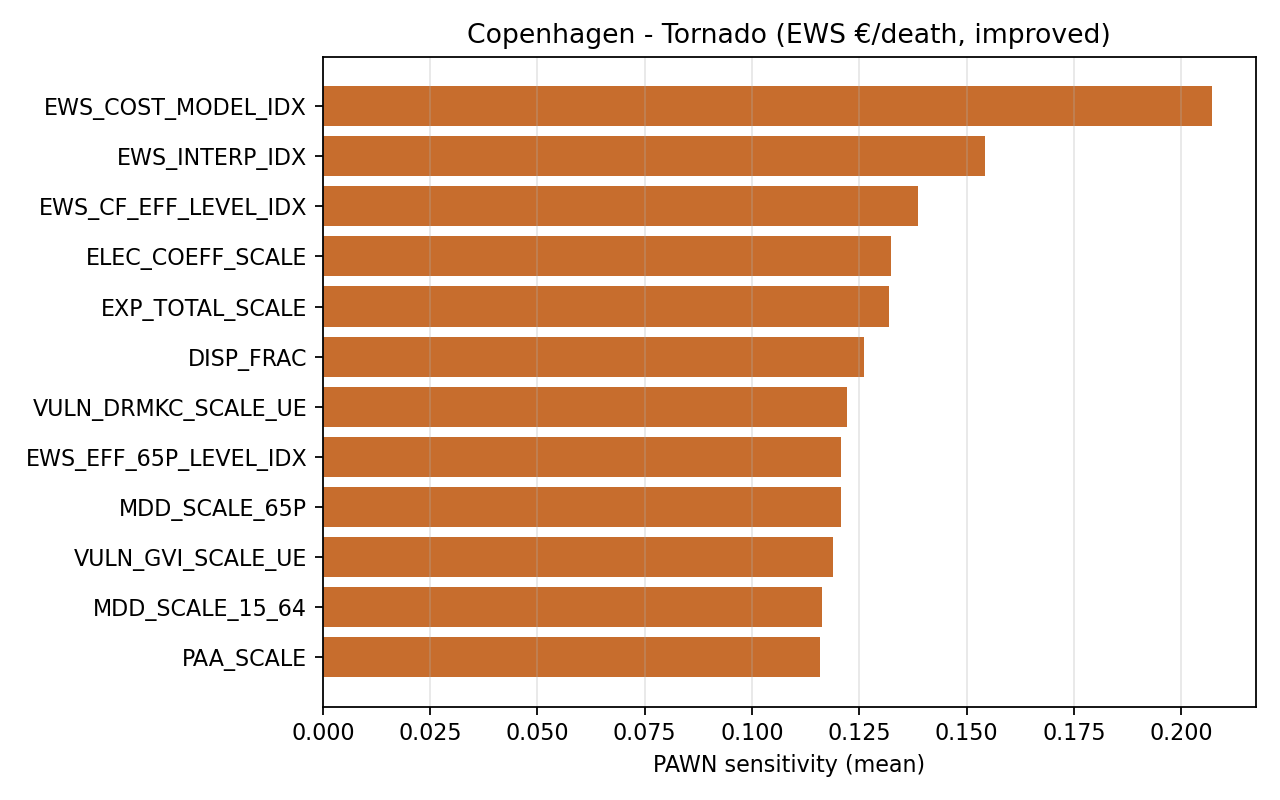

### unc_freq_curve_copenhagen_improved_fast.png

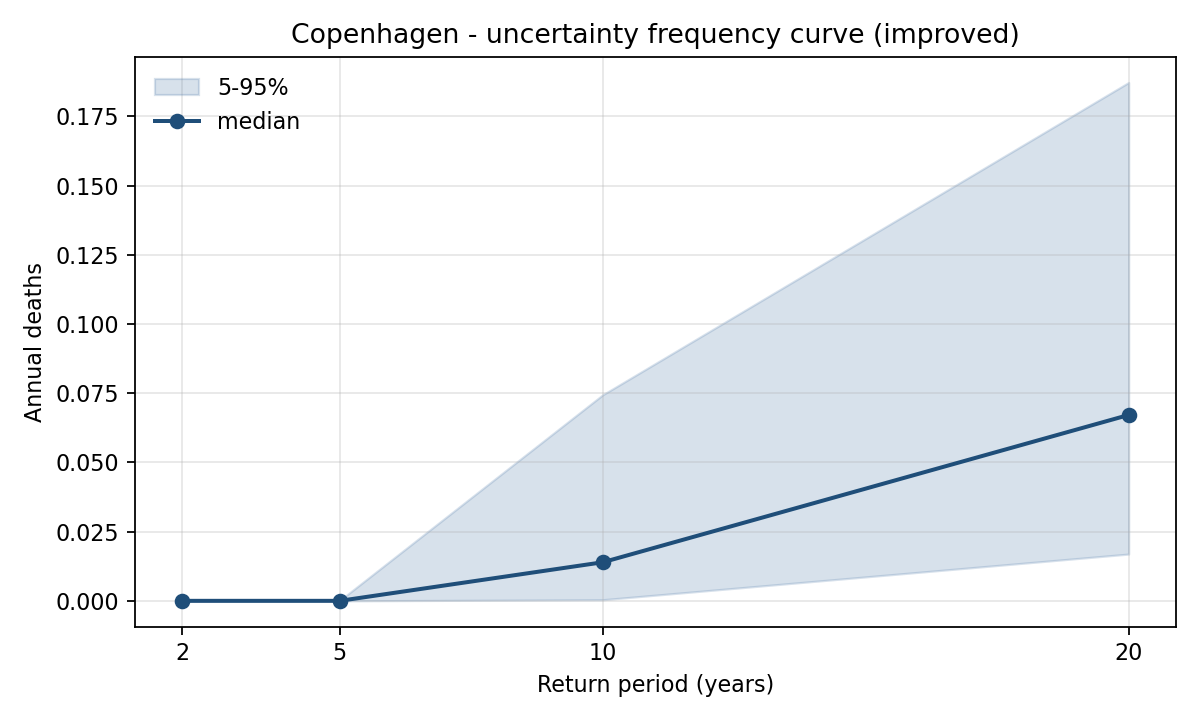

### unc_distribution_vuln_svi_mean_copenhagen_improved_fast.png

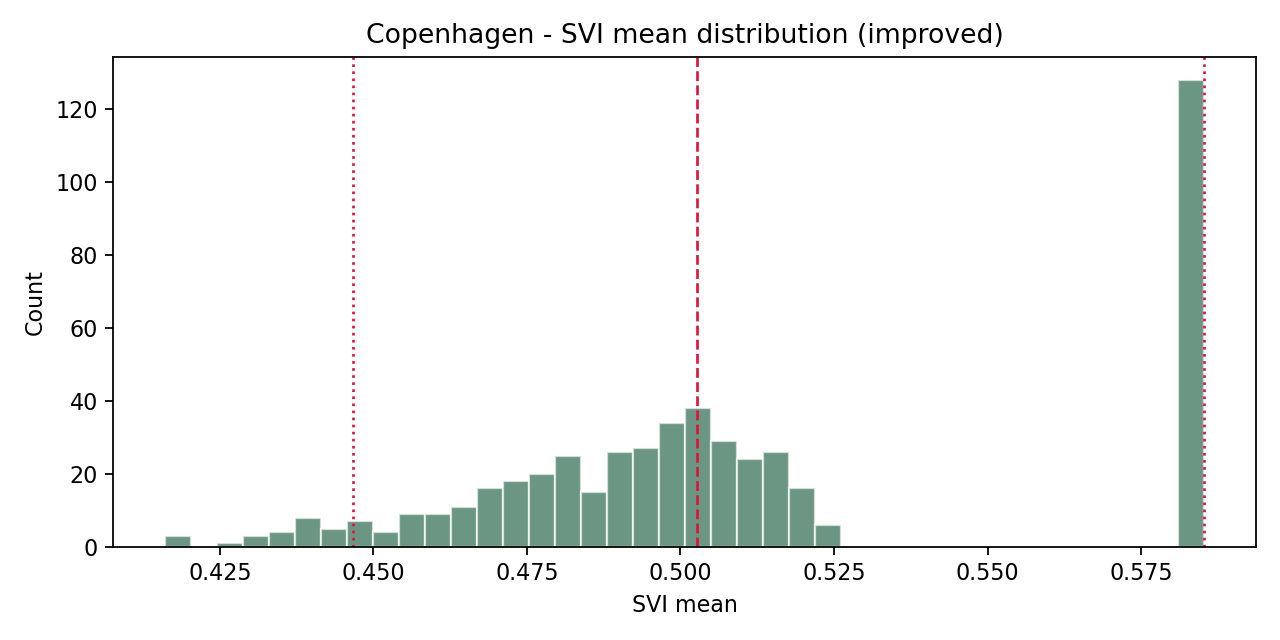

### unc_distribution_vuln_2050_svi_mean_copenhagen_improved_fast.png

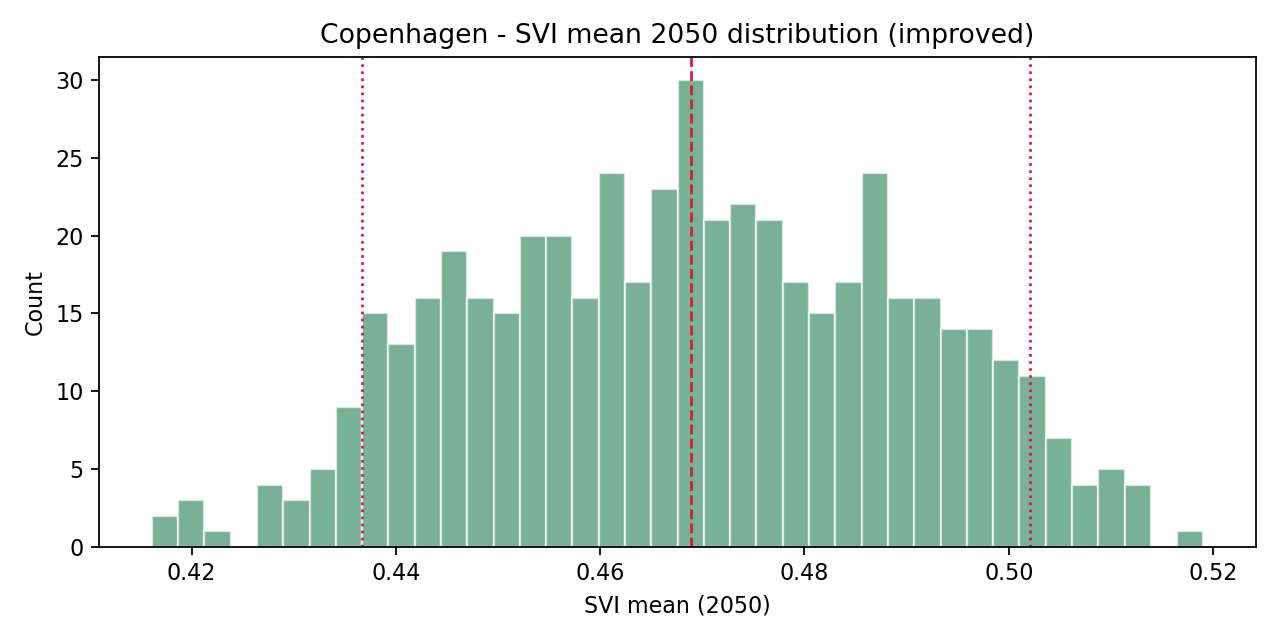

### sens_tornado_vuln_svi_gap_copenhagen_improved_fast.png

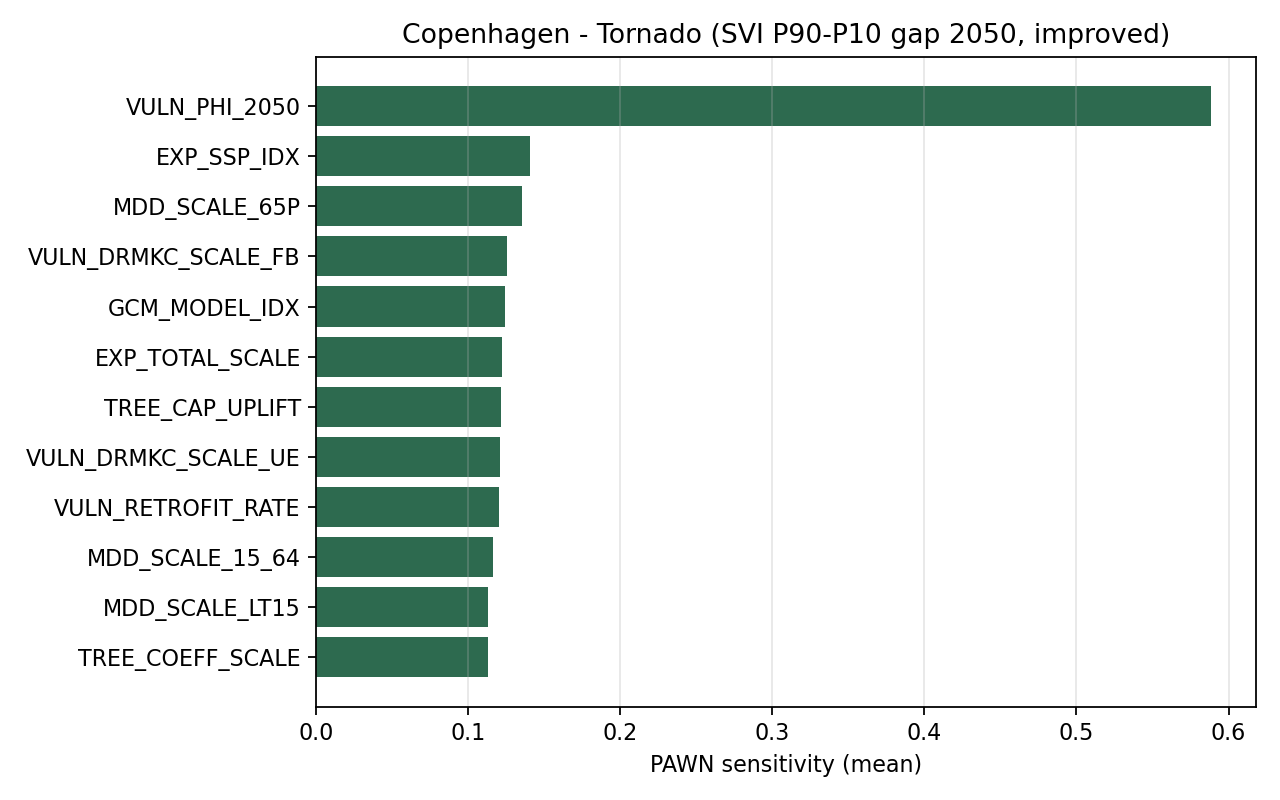

### sens_tornado_vuln_svi_mean_copenhagen_improved_fast.png

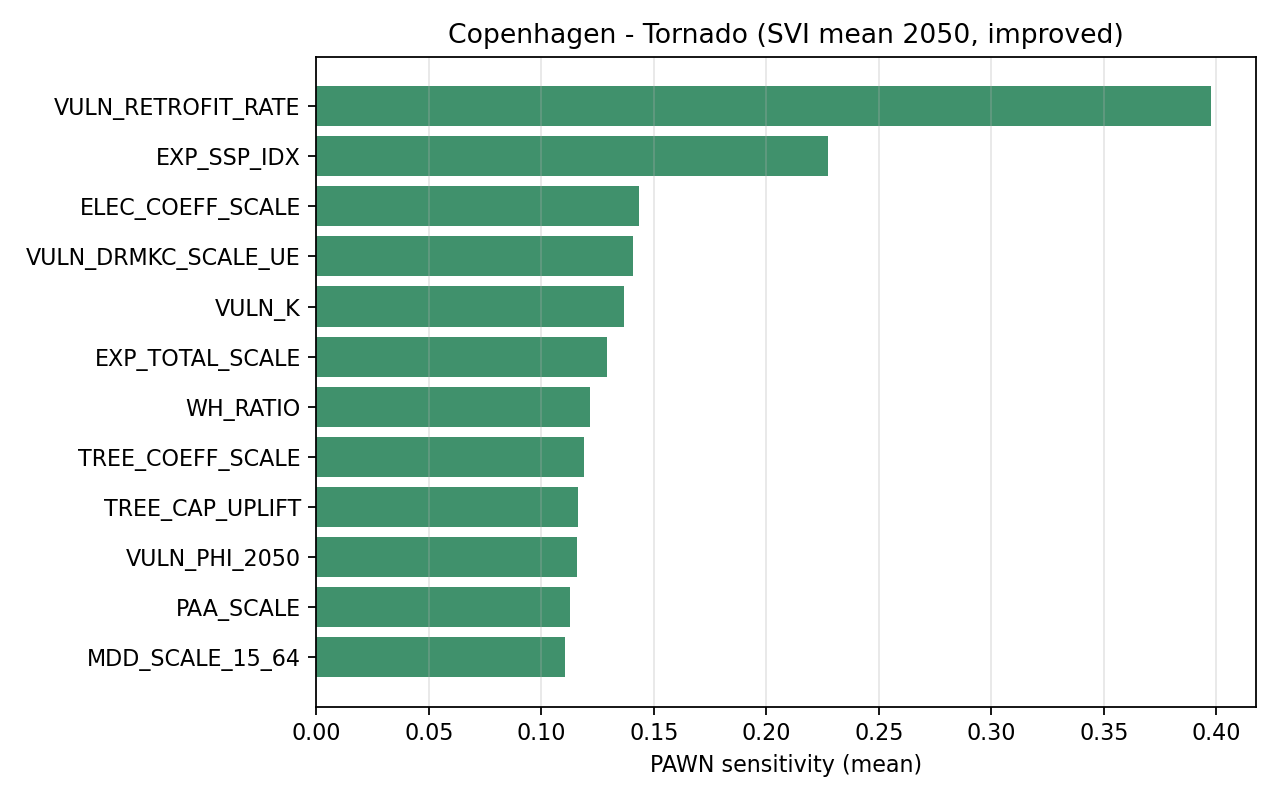

Generated headline figures displayed: 11

In [7]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

display(Markdown('## Masselot-main NB09 output paths'))
for _k, _v in sorted(paths.items()):
    display(Markdown(f'- {_k}: {_v}'))

samples = pd.read_csv(paths['samples'])
display(Markdown('## Headline sample IF-family counts'))
if 'if_family' in samples.columns:
    display(samples['if_family'].value_counts().rename_axis('if_family').to_frame('n'))

fig_dir = Path(paths['samples']).parent
fig_order = [
    'unc_distribution_aai_agg_copenhagen_improved_fast.png',
    'unc_cdf_aai_agg_copenhagen_improved_fast.png',
    'sens_tornado_aai_agg_copenhagen_improved_fast.png',
    'unc_distribution_cba_ews_copenhagen_improved_fast.png',
    'unc_cdf_cba_ews_copenhagen_improved_fast.png',
    'sens_tornado_cba_ews_copenhagen_improved_fast.png',
    'unc_freq_curve_copenhagen_improved_fast.png',
    'unc_distribution_vuln_svi_mean_copenhagen_improved_fast.png',
    'unc_distribution_vuln_2050_svi_mean_copenhagen_improved_fast.png',
    'sens_tornado_vuln_svi_gap_copenhagen_improved_fast.png',
    'sens_tornado_vuln_svi_mean_copenhagen_improved_fast.png',
]
display(Markdown('## Generated headline NB09 figures'))
shown = 0
for fig_name in fig_order:
    fig_path = fig_dir / fig_name
    if fig_path.exists():
        display(Markdown(f'### {fig_name}'))
        display(Image(filename=str(fig_path)))
        shown += 1
display(Markdown(f'Generated headline figures displayed: {shown}'))